# Lab 3: Mine Crafting


As with previous labs, be sure to submit only the `lab3.ipynb` and `lab3.html` version of the lab in your github `Lab3` folder. No more, and no less.

## Introduction

Imagine you are a scientist for a mining company that operates a vertical mine at the Earth's
equator. This is one of the deepest mines on Earth; it's roughly 4 km to the bottom of the shaft.
Your boss proposes to measure the vertical depth of the shaft by dropping a 1 kg test mass and
accurately measuring the time to hit the bottom.

You will be guided in your investigations below and submit your report in the form of this notebook. Be sure to be quantitative in nature, produce highly polished plots, with appropriate titles, units, etc.


A table of relevant physical constants is below. Good luck!

| Quantity | Value |
|----------|-------|
|  Gravitational Constant ($G$)        |  $6.6743 \times 10^{-11}$ m$^3$/kg/s$^2$  | 
|  Gravitational Acceleration ($g_o$)  |  9.81 m/s$^2$ (approximate) | 
|  Mass of the Earth ($M_{\oplus}$)    |  $5.972 \times 10^{24}$ kg      | 
|  Mass of the Moon ($M_{m}$)          |  $7.35 \times 10^{22}$ kg     | 
|  Radius of the Earth ($R_{\oplus}$)  |  6378.1 km     | 
|  Radius of the Moon ($R_{m}$)        |   1738.1 km    | 
|  Earth's Rotation Rate at the Equator| $7.272 \times 10^{-5} $ rad/s  | 

In [23]:
import numpy as np 
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

G = 6.6743e-11
g0 = 9.81

M_E = 5.972e24
M_m = 7.35e22

R_E = 6378.1
R_m = 1738.1

omega_E = 7.272e-5

## Part 1: The Ideal Case

In this section and the following sections, we calculate the time for the 1 kg test mass to reach the bottom of the mineshaft under a series of increasingly complex assumptions. Remember that a projectile experiencing a constant gravitational force, plus a drag force, obeys the following second
order differential equation:

$$
\frac{d^2y}{dt^2} = -g + \alpha \left| \frac{dy}{dt} \right|^{\gamma}
\tag{1}
$$



where $t$ is time, $y$ is the height, $g$ is the gravitational acceleration,
$\alpha$ is the drag coefficient, and $\gamma$ is the speed dependence
of the drag. For example, for $\gamma=2$, the drag force grows proportionally
to the speed *squared*.  **Hint**: pay particular attention to the sign
conventions in your implementation! The drag, by definition, should *oppose*
the direction of motion.

1. First, make a simple calculation of how long a test mass would 
            take to reach the bottom of the 4km shaft assuming no drag. This is the simple
            free-fall algebraic expression you know from PHYS 171.

2. Next, reduce (1) into a *system* of coupled
            first order differential equations by setting the velocity $v = dy/dt$.

3. Numerically solve (1) using `solve_ivp` assuming $\alpha=0$.
            Plot the position and velocity as a function of time.                              
            Draw a horizontal dashed line at the depth of the bottom of the shaft,
            to make it easy to see.
            Make the plot look nice, including displaying the position on the left axes,
            and plotting the velocity on a second right axis, using matplotlib `twinx`
            capability.        
   In your notebook, label this figure clearly as **Figure 1**.

4. Using the `events` detection capability of `solve_ivp`,
            calculate the time at which the mass hits the bottom of the shaft
            in the case of zero drag ($\alpha=0$). Compare this to your analytic calculation
            and discuss any differences you might see.


Starting with 

$$
\frac{d^2 y}{dt^2} = -g
$$

Assuming the mass starts from rest at the top of the shaft,

$$
y(0) = 0, \qquad v(0) = 0
$$

the position is

$$
y(t) = -\frac{1}{2}gt^2
$$

The bottom of the shaft is at

$$
y = -D
$$

where

$$
D = 4000 \ \mathrm{m}
$$

Therefore,

$$
-D = -\frac{1}{2}gt^2
$$

so

$$
D = \frac{1}{2}gt^2
$$

Solving for the time gives

$$
t = \sqrt{\frac{2D}{g}}
$$

Using \(D = 4000 \ \mathrm{m}\) and \(g = 9.81 \ \mathrm{m/s^2}\),

$$
t = \sqrt{\frac{2(4000)}{9.81}}
$$

$$
t \approx 28.56 \ \mathrm{s}
$$

In [24]:
D = 4000         

alpha = 0
gamma = 2

y0 = 0           
v0 = 0           

t_analytic = np.sqrt(2 * D / g0)

print(f"Analytic no-drag time: {t_analytic:.4f} s")

Analytic no-drag time: 28.5569 s


Numerical no-drag impact time: 28.5569 s
Difference from analytic result: -7.1054e-15 s


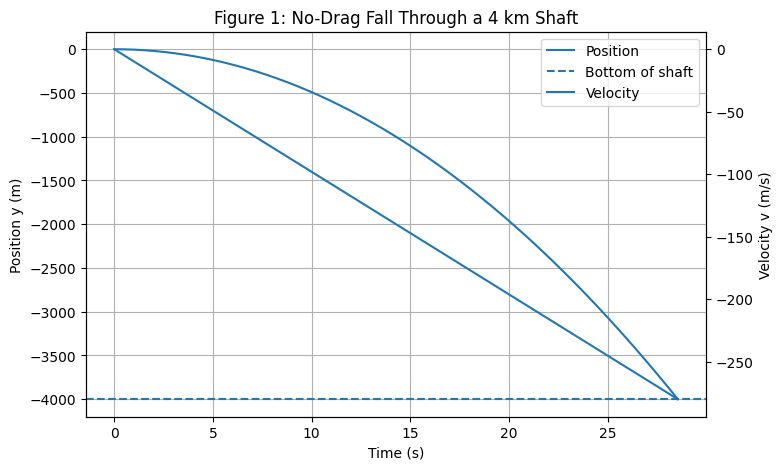

In [25]:
def falling_mass(t, state, g, alpha, gamma):
    y, v = state
    
    dydt = v
    
    if v == 0:
        drag = 0
    else:
        drag = -alpha * np.sign(v) * abs(v)**gamma
    
    dvdt = -g + drag
    
    return [dydt, dvdt]

def hit_bottom(t, state, g, alpha, gamma):
    y, v = state
    return y + D

hit_bottom.terminal = True
hit_bottom.direction = -1

sol = solve_ivp(
    falling_mass,
    t_span=(0, 100),
    y0=[y0, v0],
    args=(g0, alpha, gamma),
    events=hit_bottom,
    dense_output=True,
    max_step=0.1
)

t_hit = sol.t_events[0][0]

print(f"Numerical no-drag impact time: {t_hit:.4f} s")
print(f"Difference from analytic result: {t_hit - t_analytic:.4e} s")

t_plot = np.linspace(0, t_hit, 1000)
y_plot, v_plot = sol.sol(t_plot)

fig, ax1 = plt.subplots(figsize=(8, 5))

ax1.plot(t_plot, y_plot, label="Position")
ax1.axhline(-D, linestyle="--", label="Bottom of shaft")
ax1.set_xlabel("Time (s)")
ax1.set_ylabel("Position y (m)")
ax1.grid(True)

ax2 = ax1.twinx()
ax2.plot(t_plot, v_plot, label="Velocity")
ax2.set_ylabel("Velocity v (m/s)")

plt.title("Figure 1: No-Drag Fall Through a 4 km Shaft")

lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc="best")

plt.show()

## Part 2: Including Drag and a Variable g

In practice, we cannot ignore drag, and we should also not assume that $g$ is a constant. If you
approximate that the mass of the Earth is distributed homogenously (which it is not!), then the
gravitational constant $g$ will depend on your distance $r$ from the center of the Earth in a simple
linear way:

$$
 g(r) = g_o \left( \frac{r}{R_{\oplus}} \right)
 \tag{2}
$$

where $g_o$ is the gravity at the surface, and $R_{\oplus}$ is the radius of the Earth.

1. Make a new plot that shows the velocity and position as a function of                       
            time assuming $g(y)$. Be careful with coordinate systems!
            The test mass' position should be at the Earth radius at $t=0$, and falling down.
            But for plotting purposes, it will be useful to plot the height
            above the bottom of the shaft.        
            In your notebook, label this figure clearly as **Figure 2**.

2. What effect does incorporating a height-dependent $g$ have on the fall time? Explain.

3. Now, turn on drag, and replot the position and velocity.
            For most things, $\gamma=2$ is a good assumption.
            How can you calibrate the value of $\alpha$? Think about what we did in Lecture 15/16,
            where we assumed a sky-diver's terminal speed was 50 m/s.
            You should assume the same of the test mass.
            What affect does including drag have on the fall time?



Impact time with height-dependent g: 28.5584 s
Impact time with constant g: 28.5569 s
Difference: 0.001493 s


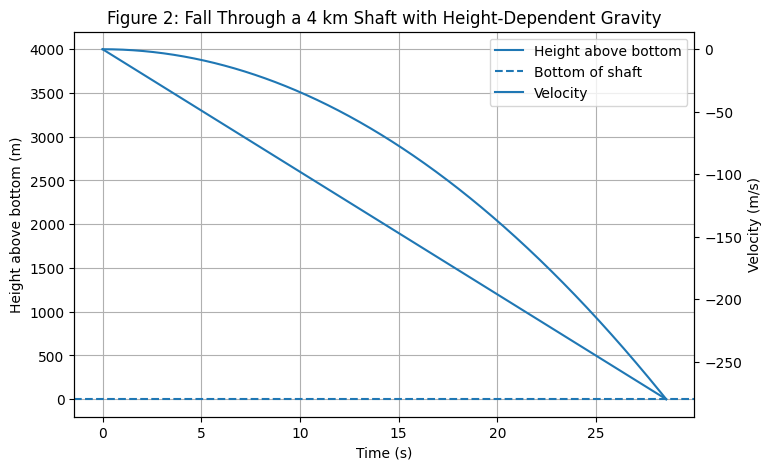

There is a very minimal effect due to a height dependent g.


In [26]:
R_E_m = R_E * 1000
r_initial = R_E_m
r_bottom = R_E_m - D

def falling_variable_g(t, state):
    r, v = state
    drdt = v
    dvdt = -g0 * r / R_E_m
    return [drdt, dvdt]

def hit_bottom_r(t, state):
    r, v = state
    return r - r_bottom

hit_bottom_r.terminal = True
hit_bottom_r.direction = -1

sol_g = solve_ivp(
    falling_variable_g,
    t_span=(0, 100),
    y0=[r_initial, v0],
    events=hit_bottom_r,
    dense_output=True,
    max_step=0.1
)

t_hit_g = sol_g.t_events[0][0]

print(f"Impact time with height-dependent g: {t_hit_g:.4f} s")
print(f"Impact time with constant g: {t_analytic:.4f} s")
print(f"Difference: {t_hit_g - t_analytic:.6f} s")

t_plot_g = np.linspace(0, t_hit_g, 1000)
r_plot_g, v_plot_g = sol_g.sol(t_plot_g)

height_above_bottom_g = r_plot_g - r_bottom

fig, ax1 = plt.subplots(figsize=(8, 5))

ax1.plot(t_plot_g, height_above_bottom_g, label="Height above bottom")
ax1.axhline(0, linestyle="--", label="Bottom of shaft")
ax1.set_xlabel("Time (s)")
ax1.set_ylabel("Height above bottom (m)")
ax1.grid(True)

ax2 = ax1.twinx()
ax2.plot(t_plot_g, v_plot_g, label="Velocity")
ax2.set_ylabel("Velocity (m/s)")

plt.title("Figure 2: Fall Through a 4 km Shaft with Height-Dependent Gravity")

lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc="best")

plt.show()

print('There is a very minimal effect due to a height dependent g.')

We calibrated alpha by requiring the drag force to balance gravity at terminal speed.
Using v_terminal = 50.0 m/s and gamma = 2, we set alpha = g0 / v_terminal**gamma.
This gives alpha = 0.003924.
Impact time with height-dependent g and drag: 83.5447 s


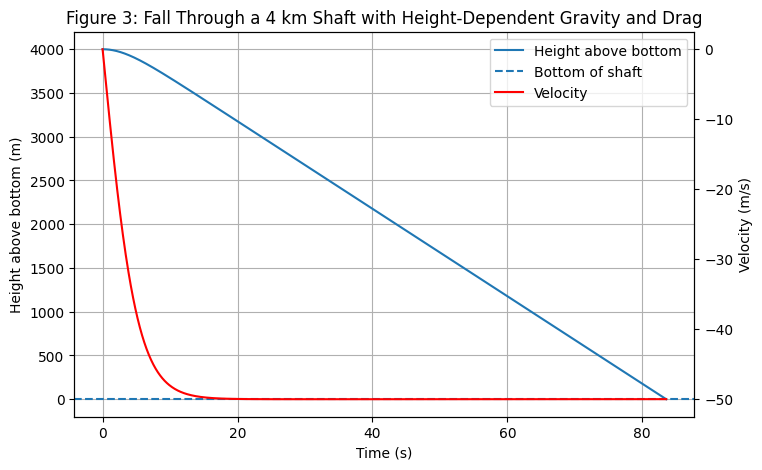

Constant g, no drag impact time: 28.5569 s
Height-dependent g, no drag impact time: 28.5584 s
Height-dependent g with drag impact time: 83.5447 s
Change from height-dependent g alone: 54.9863 s
The drag enforces a terminal velocity early on.


In [27]:
v_terminal = 50
alpha_drag = g0 / v_terminal**gamma
print(f"We calibrated alpha by requiring the drag force to balance gravity at terminal speed.")
print(f"Using v_terminal = {v_terminal:.1f} m/s and gamma = {gamma}, we set alpha = g0 / v_terminal**gamma.")
print(f"This gives alpha = {alpha_drag:.6f}.")

def falling_variable_g_drag(t, state):
    r, v = state
    drdt = v
    g_r = g0 * r / R_E_m
    drag = -alpha_drag * np.sign(v) * abs(v)**gamma
    dvdt = -g_r + drag
    return [drdt, dvdt]

sol_drag = solve_ivp(
    falling_variable_g_drag,
    t_span=(0, 1000),
    y0=[r_initial, v0],
    events=hit_bottom_r,
    dense_output=True,
    max_step=0.1
)

t_hit_drag = sol_drag.t_events[0][0]

print(f"Impact time with height-dependent g and drag: {t_hit_drag:.4f} s")

t_plot_drag = np.linspace(0, t_hit_drag, 1000)
r_plot_drag, v_plot_drag = sol_drag.sol(t_plot_drag)

height_above_bottom_drag = r_plot_drag - r_bottom

fig, ax1 = plt.subplots(figsize=(8, 5))

ax1.plot(t_plot_drag, height_above_bottom_drag, label="Height above bottom")
ax1.axhline(0, linestyle="--", label="Bottom of shaft")
ax1.set_xlabel("Time (s)")
ax1.set_ylabel("Height above bottom (m)")
ax1.grid(True)

ax2 = ax1.twinx()
ax2.plot(t_plot_drag, v_plot_drag,color='r', label="Velocity")
ax2.set_ylabel("Velocity (m/s)")

plt.title("Figure 3: Fall Through a 4 km Shaft with Height-Dependent Gravity and Drag")

lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc="best")

plt.show()

print(f"Constant g, no drag impact time: {t_analytic:.4f} s")
print(f"Height-dependent g, no drag impact time: {t_hit_g:.4f} s")
print(f"Height-dependent g with drag impact time: {t_hit_drag:.4f} s")
print(f"Change from height-dependent g alone: {t_hit_drag - t_hit_g:.4f} s")
print('The drag enforces a terminal velocity early on.')

## Part 3: The Coriolis Force

Since the Earth is rotating, there is a Coriolis force on the test mass as it falls.
The force can be quite large.
For example, imagine the mine shaft is on the Earth's equator and pointed towards
the Earth's center.
The equator rotates at about half a kilometer per second.
So once the test mass has fallen for some time, it will bump into the wall,
unless the shaft is very wide.
The Coriolis force $\vec{F_c}$ is:

$$
 \vec{F_c} = -2m \, \left( \vec{\Omega} \times \vec{v} \right)
 \tag{3}
$$

where $\vec{\Omega}$ is the Earth's rotation rate for a vector along $\hat{z}$ and $m$ is the mass of the object (1 kg for the test mass in this case).
For a mine shaft on the equator, we might pick a right-handed coordinate system
with the $\hat{x}$ axis along the East, $\hat{y}$ down into the mine shaft,
and $\hat{z}$ along the North.
This implies the component of the force are:

\begin{equation}
        F_{c_x} = + 2m \, \Omega v_y     \tag{4}
\end{equation}
\begin{equation}
        F_{c_y} = - 2m \, \Omega v_x     \tag{5}
\end{equation}
\begin{equation}
        F_{c_z} = 0     \tag{6}
\end{equation}

1. Extend and update your differential equations of motion 
                to include the Coriolis force. You will need to add a Coriolis
                acceleration term to your equation for the depth coordinate (remember, $F=ma$),
                and additionally, start tracking the velocity and position 
                in the transverse direction (``side-to-side'' in the shaft).

2. Plot the transverse position of the object as a function of depth, initially assuming $\alpha=0$.
                        That is, both axes will have units of distance. 
                Plot ``dots" every few seconds so that you can see
                how the particle moves over time.
                Note that your depth and transverse axes are likely to have very
                different length scales.
                The depth will have a range of 4 km,
   while the transverse direction is about 5m.       
                In your report, this should be **Figure 3**.                

3. If the mine shaft is 5m wide, and you drop the test mass 
                        from the center, does the test mass reach the bottom?
                Or does it bump into the wall first?

4. Now turn drag back on. Does drag make any difference here?




Impact time with Coriolis force and no drag: 28.5584 s


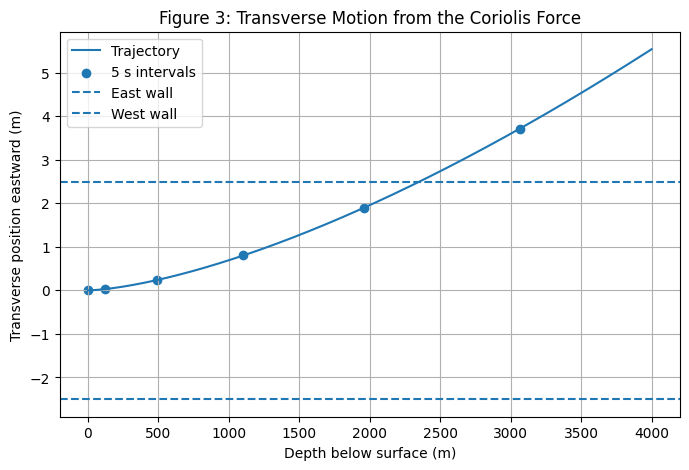

With no drag, the mass hits the wall first at t = 21.9071 s.
It hits the wall at depth 2353.8657 m.
With drag, the mass hits the wall first at t = 75.4567 s.
It hits the wall at depth 3595.7163 m.
No drag: wall/bottom event time = 21.9071 s
With drag: wall/bottom event time = 75.4567 s
Drag changes the wall-hit depth from 2353.8657 m to 3595.7163 m.


In [28]:
shaft_width = 5
wall_position = shaft_width / 2

state0_cor = [0, 0, 0, 0]

def coriolis_fall(t, state, alpha_value):
    x, y, vx, vy = state

    speed = np.sqrt(vx**2 + vy**2)
    g_y = g0 * (R_E_m - y) / R_E_m

    if speed == 0:
        drag_x = 0
        drag_y = 0
    else:
        drag_x = -alpha_value * speed**(gamma - 1) * vx
        drag_y = -alpha_value * speed**(gamma - 1) * vy

    dxdt = vx
    dydt = vy

    dvxdt = 2 * omega_E * vy + drag_x
    dvydt = g_y - 2 * omega_E * vx + drag_y

    return [dxdt, dydt, dvxdt, dvydt]

def hit_bottom_depth(t, state):
    return state[1] - D

hit_bottom_depth.terminal = True
hit_bottom_depth.direction = 1

def hit_wall(t, state):
    return wall_position - abs(state[0])

hit_wall.terminal = True
hit_wall.direction = -1

sol_cor_no_drag = solve_ivp(
    lambda t, state: coriolis_fall(t, state, 0),
    t_span=(0, 200),
    y0=state0_cor,
    events=hit_bottom_depth,
    dense_output=True,
    max_step=0.05
)

t_hit_cor_no_drag = sol_cor_no_drag.t_events[0][0]

print(f"Impact time with Coriolis force and no drag: {t_hit_cor_no_drag:.4f} s")

t_cor = np.linspace(0, t_hit_cor_no_drag, 1000)
x_cor, depth_cor, vx_cor, vy_cor = sol_cor_no_drag.sol(t_cor)

dot_times = np.arange(0, t_hit_cor_no_drag, 5)
x_dots, depth_dots, vx_dots, vy_dots = sol_cor_no_drag.sol(dot_times)

plt.figure(figsize=(8, 5))

plt.plot(depth_cor, x_cor, label="Trajectory")
plt.scatter(depth_dots, x_dots, label="5 s intervals")
plt.axhline(wall_position, linestyle="--", label="East wall")
plt.axhline(-wall_position, linestyle="--", label="West wall")

plt.xlabel("Depth below surface (m)")
plt.ylabel("Transverse position eastward (m)")
plt.title("Figure 3: Transverse Motion from the Coriolis Force")
plt.grid(True)
plt.legend()
plt.show()

sol_cor_no_drag_wall = solve_ivp(
    lambda t, state: coriolis_fall(t, state, 0),
    t_span=(0, 200),
    y0=state0_cor,
    events=[hit_bottom_depth, hit_wall],
    dense_output=True,
    max_step=0.05
)

hit_bottom_no_drag = len(sol_cor_no_drag_wall.t_events[0]) > 0
hit_wall_no_drag = len(sol_cor_no_drag_wall.t_events[1]) > 0

if hit_bottom_no_drag:
    t_event_no_drag = sol_cor_no_drag_wall.t_events[0][0]
    x_event_no_drag, depth_event_no_drag, vx_event_no_drag, vy_event_no_drag = sol_cor_no_drag_wall.sol(t_event_no_drag)
    print(f"With no drag, the mass reaches the bottom first at t = {t_event_no_drag:.4f} s.")
    print(f"The transverse displacement at the bottom is {x_event_no_drag:.4f} m.")
elif hit_wall_no_drag:
    t_event_no_drag = sol_cor_no_drag_wall.t_events[1][0]
    x_event_no_drag, depth_event_no_drag, vx_event_no_drag, vy_event_no_drag = sol_cor_no_drag_wall.sol(t_event_no_drag)
    print(f"With no drag, the mass hits the wall first at t = {t_event_no_drag:.4f} s.")
    print(f"It hits the wall at depth {depth_event_no_drag:.4f} m.")

sol_cor_drag_wall = solve_ivp(
    lambda t, state: coriolis_fall(t, state, alpha_drag),
    t_span=(0, 1000),
    y0=state0_cor,
    events=[hit_bottom_depth, hit_wall],
    dense_output=True,
    max_step=0.05
)

hit_bottom_drag = len(sol_cor_drag_wall.t_events[0]) > 0
hit_wall_drag = len(sol_cor_drag_wall.t_events[1]) > 0

if hit_bottom_drag:
    t_event_drag = sol_cor_drag_wall.t_events[0][0]
    x_event_drag, depth_event_drag, vx_event_drag, vy_event_drag = sol_cor_drag_wall.sol(t_event_drag)
    print(f"With drag, the mass reaches the bottom first at t = {t_event_drag:.4f} s.")
    print(f"The transverse displacement at the bottom is {x_event_drag:.4f} m.")
elif hit_wall_drag:
    t_event_drag = sol_cor_drag_wall.t_events[1][0]
    x_event_drag, depth_event_drag, vx_event_drag, vy_event_drag = sol_cor_drag_wall.sol(t_event_drag)
    print(f"With drag, the mass hits the wall first at t = {t_event_drag:.4f} s.")
    print(f"It hits the wall at depth {depth_event_drag:.4f} m.")

print(f"No drag: wall/bottom event time = {t_event_no_drag:.4f} s")
print(f"With drag: wall/bottom event time = {t_event_drag:.4f} s")

if hit_wall_no_drag and hit_wall_drag:
    print(f"Drag changes the wall-hit depth from {depth_event_no_drag:.4f} m to {depth_event_drag:.4f} m.")
elif hit_bottom_no_drag and hit_bottom_drag:
    print(f"Drag changes the bottom transverse displacement from {x_event_no_drag:.4f} m to {x_event_drag:.4f} m.")
else:
    print("Drag changes which event happens first.")

## Part 4: An infinitely deep mine


Now, let us consider the theoretical case of an infinitely deep mine -- that is,
a tunnel which traverses the full diameter of the Earth.
For convenience, imagine the tunnel goes from pole-to-pole,
such that $\vec{\Omega} \times \vec{v} = 0$, and the Coriolis force
can be neglected, as well as the drag force.

Additionally, continue assuming a constant density Earth.

1. Again, plot the depth and velocity as a function of time.
               (Be careful with the meaning of $y$, as the particle can theoretically
                traverse fully through to the other side of the Earth.)
                Comment on what you see in the graph.       
                In your notebook, label this figure clearly as **Figure 4**.                

2. How long will it take for the object to reach the other side? 
                At what time does the object reach the center of the Earth,
                and at what speed?

3. How does this ``crossing-time" compare to the orbital period, where you assume
                the object is on a circular orbit, in centripetal balance
                with the attractive force of the gravity.
                \begin{equation}
                        \frac{v^2}{R} = \frac{GM}{R^2}   \tag{7}
                \end{equation}
                gives the orbital speed $v$ for a given Earth radius $R$ and 
                Earth mass $M$.





Time to reach the other side: 2533.1507 s
Time to reach the other side: 42.2192 min


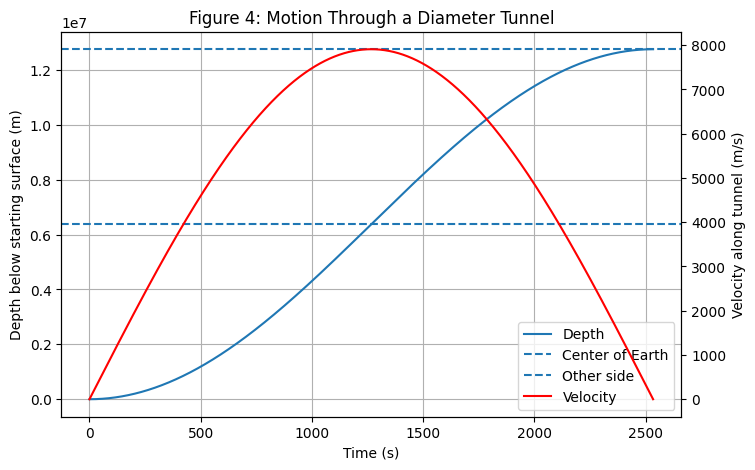

Time to reach the center: 1266.5754 s
Time to reach the center: 21.1096 min
Speed at the center: 7910.0671 m/s
Orbital speed at Earth's surface: 7905.2771 m/s
Orbital period at Earth's surface: 5069.3712 s
Orbital period at Earth's surface: 84.4895 min
Tunnel crossing time: 2533.1507 s
Half the orbital period: 2534.6856 s
For a constant-density Earth, the gravitational force is linear in distance from the center.
Therefore the motion through the tunnel is simple harmonic motion.
The object speeds up until it reaches the center, where its speed is maximum, and then slows down symmetrically as it approaches the other side.
The crossing time is one half of the corresponding circular orbital period.


In [29]:
R_tunnel = R_E if R_E > 1e5 else R_E * 1000

omega_tunnel = np.sqrt(g0 / R_tunnel)

state0_tunnel = [R_tunnel, 0]

def tunnel_fall(t, state):
    y, v = state
    dydt = v
    dvdt = -omega_tunnel**2 * y
    return [dydt, dvdt]

t_cross = np.pi / omega_tunnel

sol_tunnel = solve_ivp(
    tunnel_fall,
    t_span=(0, t_cross),
    y0=state0_tunnel,
    dense_output=True,
    max_step=1
)

print(f"Time to reach the other side: {t_cross:.4f} s")
print(f"Time to reach the other side: {t_cross / 60:.4f} min")

t_plot_tunnel = np.linspace(0, t_cross, 2000)
y_plot_tunnel, v_plot_tunnel = sol_tunnel.sol(t_plot_tunnel)

depth_plot_tunnel = R_tunnel - y_plot_tunnel
depth_velocity_plot_tunnel = -v_plot_tunnel

fig, ax1 = plt.subplots(figsize=(8, 5))

ax1.plot(t_plot_tunnel, depth_plot_tunnel, label="Depth")
ax1.axhline(R_tunnel, linestyle="--", label="Center of Earth")
ax1.axhline(2 * R_tunnel, linestyle="--", label="Other side")
ax1.set_xlabel("Time (s)")
ax1.set_ylabel("Depth below starting surface (m)")
ax1.grid(True)

ax2 = ax1.twinx()
ax2.plot(t_plot_tunnel, depth_velocity_plot_tunnel,color='r', label="Velocity")
ax2.set_ylabel("Velocity along tunnel (m/s)")

plt.title("Figure 4: Motion Through a Diameter Tunnel")

lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc="best")

plt.show()

t_center = np.pi / (2 * omega_tunnel)
v_center = np.sqrt(g0 * R_tunnel)

print(f"Time to reach the center: {t_center:.4f} s")
print(f"Time to reach the center: {t_center / 60:.4f} min")
print(f"Speed at the center: {v_center:.4f} m/s")

v_orb = np.sqrt(G * M_E / R_tunnel)
T_orb = 2 * np.pi * R_tunnel / v_orb

print(f"Orbital speed at Earth's surface: {v_orb:.4f} m/s")
print(f"Orbital period at Earth's surface: {T_orb:.4f} s")
print(f"Orbital period at Earth's surface: {T_orb / 60:.4f} min")
print(f"Tunnel crossing time: {t_cross:.4f} s")
print(f"Half the orbital period: {T_orb / 2:.4f} s")

print("For a constant-density Earth, the gravitational force is linear in distance from the center.")
print("Therefore the motion through the tunnel is simple harmonic motion.")
print("The object speeds up until it reaches the center, where its speed is maximum, and then slows down symmetrically as it approaches the other side.")
print("The crossing time is one half of the corresponding circular orbital period.")

## Part 5: A non-uniform Earth

Finally, let us consider the case of a non-uniform Earth, and continue assuming we have no drag. We know from geology
that the density increases towards the center.
It rises from about 2-3 g/cm$^3$ near the surface, to more like 13 near the center.
A simple model for the density $\rho$ as a function of distance from the center of the Earth $r$ is:

$$
\rho(r) = \rho_n \left( 1 - \frac{r^2}{R_{\oplus}^2} \right)^n   \tag{8}
$$

where $n$ is some exponent, and $\rho_n$ is a normalizing constant.
The case of $n=0$ is the constant density Earth, while $n=2$ is closer to the real value.
Note that the total mass of the Earth, $M$, must be conserved.
Since the mass is the volume integral over the density:

\begin{equation}
        M = \int_V \rho(r) dV = \int_0^{2\pi} \int_0^{\pi} \int_0^{R_{\oplus}} \rho(r) r^2 \sin \phi \, dr \, d\phi \,d\theta = 4 \pi \int_0^{R_{\oplus}} \rho(r) r^2 \, dr
        \tag{9}
\end{equation}

you will need to recompute the density constant $\rho_n$ for each case of $n>0$,
You can use the `quad` integrator for this.
Note that the analytic solution is straightforward to do by hand for $n=0$,
and still manageable for $n=1,2$.
You might consider doing that integral to make sure your method is right, 
and then you can be confident for $n>0$.

1.  Plot the normalized density profile (that is, set $\rho_n=1$) as a function of radius for $n=0, 1, 2, 9$.            
              Put them all on the same plot, with a clear legend.       
              In your notebook, label this figure clearly as **Figure 5**.

2. Now, plot the force profile as a function of radius for $n=0, 1, 2, 9$.         
                This step will show you if your normalization factor $\rho_n$
                is correct, because the surface force must be the same for all $n$.       
              In your notebook, label this figure clearly as **Figure 6**.                

3. Then, plot the position and velocity as a function of time for $n=0, 1, 2, 9$
              as you did in Figure 1/2.         
              In your notebook, label this figure clearly as **Figure 7**.              

4. For $n=0, 1, 2, 9$, compute the time to reach the center, 
                and the speed achieved there.





### Part 5, Section A (Density)

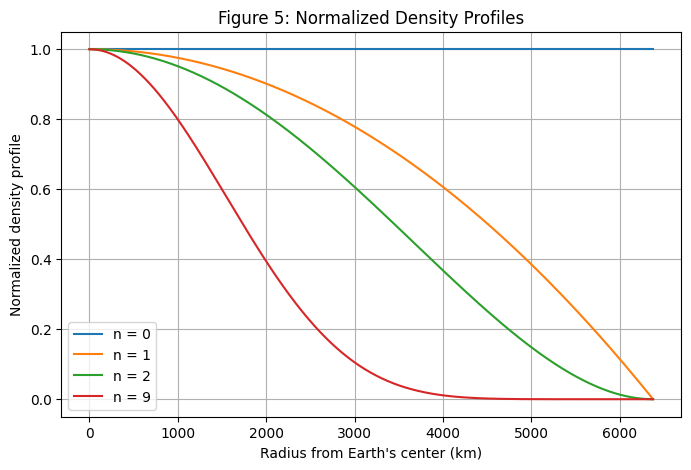

n = 0: rho_n = 5494.8674 kg/m^3
n = 1: rho_n = 13737.1685 kg/m^3
n = 2: rho_n = 24040.0449 kg/m^3
n = 9: rho_n = 135545.1214 kg/m^3


In [30]:
from scipy.integrate import quad

n_values = [0, 1, 2, 9]

r_density = np.linspace(0, R_tunnel, 1000)

def density_shape(r, n):
    return (1 - (r / R_tunnel)**2)**n

rho_constants = {}

for n in n_values:
    integral_n = quad(lambda r: density_shape(r, n) * r**2, 0, R_tunnel)[0]
    rho_constants[n] = M_E / (4 * np.pi * integral_n)

plt.figure(figsize=(8, 5))

for n in n_values:
    plt.plot(r_density / 1000, density_shape(r_density, n), label=f"n = {n}")

plt.xlabel("Radius from Earth's center (km)")
plt.ylabel("Normalized density profile")
plt.title("Figure 5: Normalized Density Profiles")
plt.grid(True)
plt.legend()
plt.show()

for n in n_values:
    print(f"n = {n}: rho_n = {rho_constants[n]:.4f} kg/m^3")

### Part 5, Section B (Forces)

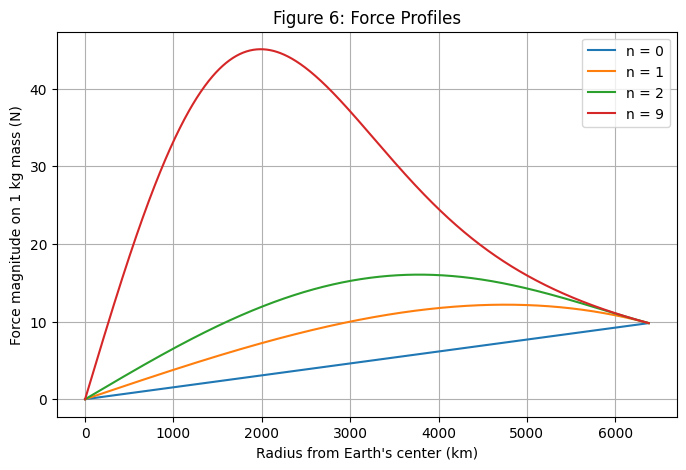

n = 0: surface force = 9.798123 N
n = 1: surface force = 9.798123 N
n = 2: surface force = 9.798123 N
n = 9: surface force = 9.798123 N


In [31]:
r_force = np.linspace(0, R_tunnel, 1000)

def enclosed_mass(r, n):
    integral_n = quad(lambda s: density_shape(s, n) * s**2, 0, r)[0]
    return 4 * np.pi * rho_constants[n] * integral_n

force_profiles = {}

for n in n_values:
    force_n = []

    for r in r_force:
        if r == 0:
            force_n.append(0)
        else:
            force_n.append(G * enclosed_mass(r, n) / r**2)

    force_profiles[n] = np.array(force_n)

plt.figure(figsize=(8, 5))

for n in n_values:
    plt.plot(r_force / 1000, force_profiles[n], label=f"n = {n}")

plt.xlabel("Radius from Earth's center (km)")
plt.ylabel("Force magnitude on 1 kg mass (N)")
plt.title("Figure 6: Force Profiles")
plt.grid(True)
plt.legend()
plt.show()

for n in n_values:
    print(f"n = {n}: surface force = {force_profiles[n][-1]:.6f} N")

### Part 5, Section C (Equations of Motion)

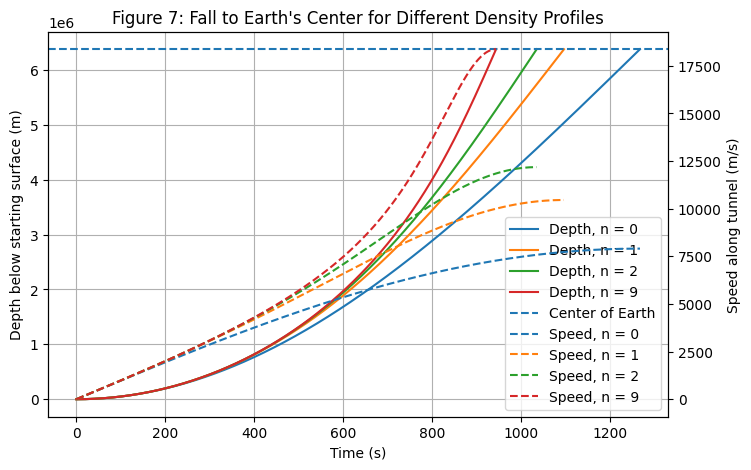

n = 0: time to center = 1267.3428 s = 21.1224 min
n = 0: speed at center = 7905.2771 m/s
n = 1: time to center = 1096.5133 s = 18.2752 min
n = 1: speed at center = 10457.6964 m/s
n = 2: time to center = 1035.0757 s = 17.2513 min
n = 2: speed at center = 12182.8475 m/s
n = 9: time to center = 943.7773 s = 15.7296 min
n = 9: speed at center = 18370.6660 m/s


In [32]:
def acceleration_from_center(y, n):
    r = abs(y)

    if r == 0:
        return 0

    g_mag = np.interp(r, r_force, force_profiles[n])

    return -np.sign(y) * g_mag

def nonuniform_tunnel_fall(t, state, n):
    y, v = state
    dydt = v
    dvdt = acceleration_from_center(y, n)
    return [dydt, dvdt]

def reach_center(t, state, n):
    y, v = state
    return y

reach_center.terminal = True
reach_center.direction = -1

solutions_nonuniform = {}
center_times = {}
center_speeds = {}

for n in n_values:
    sol_n = solve_ivp(
        lambda t, state: nonuniform_tunnel_fall(t, state, n),
        t_span=(0, 10000),
        y0=[R_tunnel, 0],
        events=lambda t, state: reach_center(t, state, n),
        dense_output=True,
        max_step=1
    )

    solutions_nonuniform[n] = sol_n
    center_times[n] = sol_n.t_events[0][0]

    y_center, v_center_n = sol_n.sol(center_times[n])
    center_speeds[n] = abs(v_center_n)

fig, ax1 = plt.subplots(figsize=(8, 5))

for n in n_values:
    t_plot_n = np.linspace(0, center_times[n], 1000)
    y_plot_n, v_plot_n = solutions_nonuniform[n].sol(t_plot_n)
    depth_plot_n = R_tunnel - y_plot_n

    ax1.plot(t_plot_n, depth_plot_n, label=f"Depth, n = {n}")

ax1.axhline(R_tunnel, linestyle="--", label="Center of Earth")
ax1.set_xlabel("Time (s)")
ax1.set_ylabel("Depth below starting surface (m)")
ax1.grid(True)

ax2 = ax1.twinx()

for n in n_values:
    t_plot_n = np.linspace(0, center_times[n], 1000)
    y_plot_n, v_plot_n = solutions_nonuniform[n].sol(t_plot_n)
    speed_plot_n = -v_plot_n

    ax2.plot(t_plot_n, speed_plot_n, linestyle="--", label=f"Speed, n = {n}")

ax2.set_ylabel("Speed along tunnel (m/s)")

plt.title("Figure 7: Fall to Earth's Center for Different Density Profiles")

lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc="best")

plt.show()

for n in n_values:
    print(f"n = {n}: time to center = {center_times[n]:.4f} s = {center_times[n] / 60:.4f} min")
    print(f"n = {n}: speed at center = {center_speeds[n]:.4f} m/s")

## Part 6: A Lunar Mine Shaft


Finally, with all of the framework in place, consider the case where the
the mine shaft is instead dug on the moon.

1. Compute the travel time to the center of the moon
                in case we dig a pole-to-pole mine shaft,
                so that we can again avoid the Coriolis force, though
                on the moon this force is very small. No drag force either,
   which is actually realistic for the moon!
3. What is the density (if you asssume a constant density) 
                of the moon compared to that of earth? 
4. How does the fall/orbit time depend on density? See if you can discover a 
        relationship between the density and the fall time. You should think beyond strictly linear 
        relationships.



This problem can actually be
done on paper, and then you can compare the answer with that for the homogenous earth
you did in Part 4.


In [33]:
R_moon = R_m if R_m > 1e5 else R_m * 1000

rho_earth_avg = M_E / ((4 / 3) * np.pi * R_tunnel**3)
rho_moon_avg = M_m / ((4 / 3) * np.pi * R_moon**3)

omega_moon = np.sqrt(G * M_m / R_moon**3)

t_moon_center = np.pi / (2 * omega_moon)
t_moon_cross = np.pi / omega_moon
T_moon_orbit = 2 * np.pi / omega_moon

g_moon_surface = G * M_m / R_moon**2

print(f"Average density of Earth: {rho_earth_avg:.4f} kg/m^3")
print(f"Average density of Moon: {rho_moon_avg:.4f} kg/m^3")
print(f"Moon/Earth density ratio: {rho_moon_avg / rho_earth_avg:.4f}")
print(f"Surface gravity on the Moon: {g_moon_surface:.4f} m/s^2")
print(f"Time to reach the center of the Moon: {t_moon_center / 60:.4f} min")
print(f"Time to cross through the full Moon: {t_moon_cross / 60:.4f} min")
print(f"Orbital period near the Moon's surface: {T_moon_orbit / 60:.4f} min")
print(f"One quarter of the orbital period: {T_moon_orbit / 4:.4f} s")

Average density of Earth: 5494.8674 kg/m^3
Average density of Moon: 3341.7538 kg/m^3
Moon/Earth density ratio: 0.6082
Surface gravity on the Moon: 1.6238 m/s^2
Time to reach the center of the Moon: 27.0853 min
Time to cross through the full Moon: 54.1707 min
Orbital period near the Moon's surface: 108.3413 min
One quarter of the orbital period: 1625.1202 s


For a constant-density sphere, the gravitational force inside the body is linear in the distance from the center:

$$
F(r) = -m \frac{GM}{R^3} r
$$

Therefore the motion through a pole-to-pole tunnel is simple harmonic motion with

$$
\omega = \sqrt{\frac{GM}{R^3}}
$$

The time to reach the center is one quarter of the oscillation period:

$$
t_{\text{center}} = \frac{\pi}{2\omega}
$$

For the Moon, this gives

$$
t_{\text{center}} \approx 1625 \ \mathrm{s}
$$

The full crossing time through the Moon is twice this:

$$
t_{\text{cross}} \approx 3250 \ \mathrm{s}
$$

The average density of a spherical body is

$$
\rho = \frac{M}{\frac{4}{3}\pi R^3}
$$

Using the given values, the Moon's average density is about

$$
\rho_{\text{Moon}} \approx 3342 \ \mathrm{kg/m^3}
$$

while the Earth's average density is about

$$
\rho_{\oplus} \approx 5495 \ \mathrm{kg/m^3}
$$

so

$$
\frac{\rho_{\text{Moon}}}{\rho_{\oplus}} \approx 0.608
$$

The Moon is therefore less dense than Earth.

The fall time depends on density through

$$
\omega^2 = \frac{GM}{R^3}
$$

but since

$$
M = \frac{4}{3}\pi R^3 \rho
$$

we can write

$$
\omega^2 = \frac{4\pi G \rho}{3}
$$

so

$$
t_{\text{center}} = \frac{\pi}{2}\sqrt{\frac{3}{4\pi G \rho}}
$$

Thus the fall time scales like

$$
t_{\text{center}} \propto \frac{1}{\sqrt{\rho}}
$$

A less dense body has a longer fall time. Since the Moon is less dense than Earth, the fall to the center of the Moon takes longer than the fall to the center of Earth.


## Part 7: Fourier Transforming Orbits

Take the solutions for n=0 and n=9 of the orbits in Part 5 (the inhomogeneous earth) and Fourier Transform them, to see what frequencies (*1/periods*) are dominant in the power spectra. Comment on what you see.

**Hint:** you could take the orbit from the previous integration in Part 5c, but it is useful to increase the integration time and sampling to get more meaningful smooth enough curves. We discussed this in class.

For an example of a spectral analysis of galactic orbits see https://articles.adsabs.harvard.edu/pdf/1982ApJ...252..308B

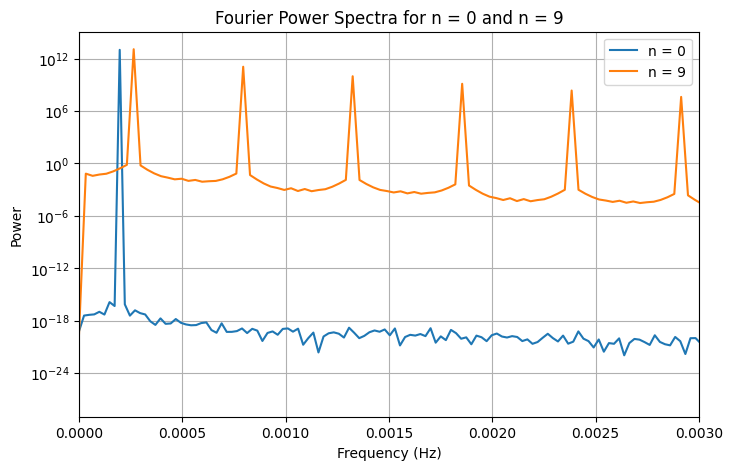

n = 0
Dominant frequency: 0.00019726 Hz
Dominant period: 5069.3712 s
Dominant period: 84.4895 min

n = 9
Dominant frequency: 0.00026489 Hz
Dominant period: 3775.1094 s
Dominant period: 62.9185 min



In [34]:
fft_ns = [0, 9]
samples_per_orbit = 4096
number_of_orbits = 8

fft_results = {}

plt.figure(figsize=(8, 5))

for n in fft_ns:
    period_n = 4 * center_times[n]
    total_time_n = number_of_orbits * period_n
    sample_count_n = samples_per_orbit * number_of_orbits

    sol_fft_n = solve_ivp(
        lambda t, state: nonuniform_tunnel_fall(t, state, n),
        t_span=(0, total_time_n),
        y0=[R_tunnel, 0],
        dense_output=True,
        max_step=0.5
    )

    t_fft_n = np.linspace(0, total_time_n, sample_count_n, endpoint=False)
    y_fft_n, v_fft_n = sol_fft_n.sol(t_fft_n)

    signal_n = y_fft_n - np.mean(y_fft_n)

    dt_n = t_fft_n[1] - t_fft_n[0]
    freq_n = np.fft.rfftfreq(sample_count_n, d=dt_n)
    power_n = np.abs(np.fft.rfft(signal_n))**2 / sample_count_n**2

    dominant_index_n = np.argmax(power_n[1:]) + 1
    dominant_freq_n = freq_n[dominant_index_n]
    dominant_period_n = 1 / dominant_freq_n

    fft_results[n] = {
        "freq": freq_n,
        "power": power_n,
        "dominant_freq": dominant_freq_n,
        "dominant_period": dominant_period_n,
        "period": period_n
    }

    plt.plot(freq_n, power_n, label=f"n = {n}")

plt.xlim(0, 0.003)
plt.yscale("log")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Power")
plt.title("Fourier Power Spectra for n = 0 and n = 9")
plt.grid(True)
plt.legend()
plt.show()

for n in fft_ns:
    print(f"n = {n}")
    print(f"Dominant frequency: {fft_results[n]['dominant_freq']:.8f} Hz")
    print(f"Dominant period: {fft_results[n]['dominant_period']:.4f} s")
    print(f"Dominant period: {fft_results[n]['dominant_period'] / 60:.4f} min")
    print()

Describe what we see here:

For \(n=0\), the Earth has constant density, so the force inside the Earth is exactly linear in radius:

$$
F(r) \propto -r
$$

Therefore the motion is simple harmonic. Because of this, the Fourier power spectrum is dominated almost entirely by one frequency. This is the fundamental oscillation frequency of the fall-through-Earth motion.

For \(n=9\), the density is much more concentrated near the center of the Earth. The force is no longer exactly linear in radius, so the motion is not a perfect sinusoid. As a result, the Fourier spectrum still has a dominant fundamental frequency, but it also contains higher-frequency peaks. These extra peaks are harmonics coming from the non-sinusoidal shape of the motion.

The dominant frequency for \(n=9\) is larger than the dominant frequency for \(n=0\), meaning the period is shorter. Physically, concentrating more mass toward the center makes the object accelerate more strongly through much of the interior, so it completes its oscillation faster.